# Nama: Istiqomah
# NIM: 4222301013
# Kelas: A Pagi

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [6]:
df = pd.read_csv('WineQT.csv')

## EDA

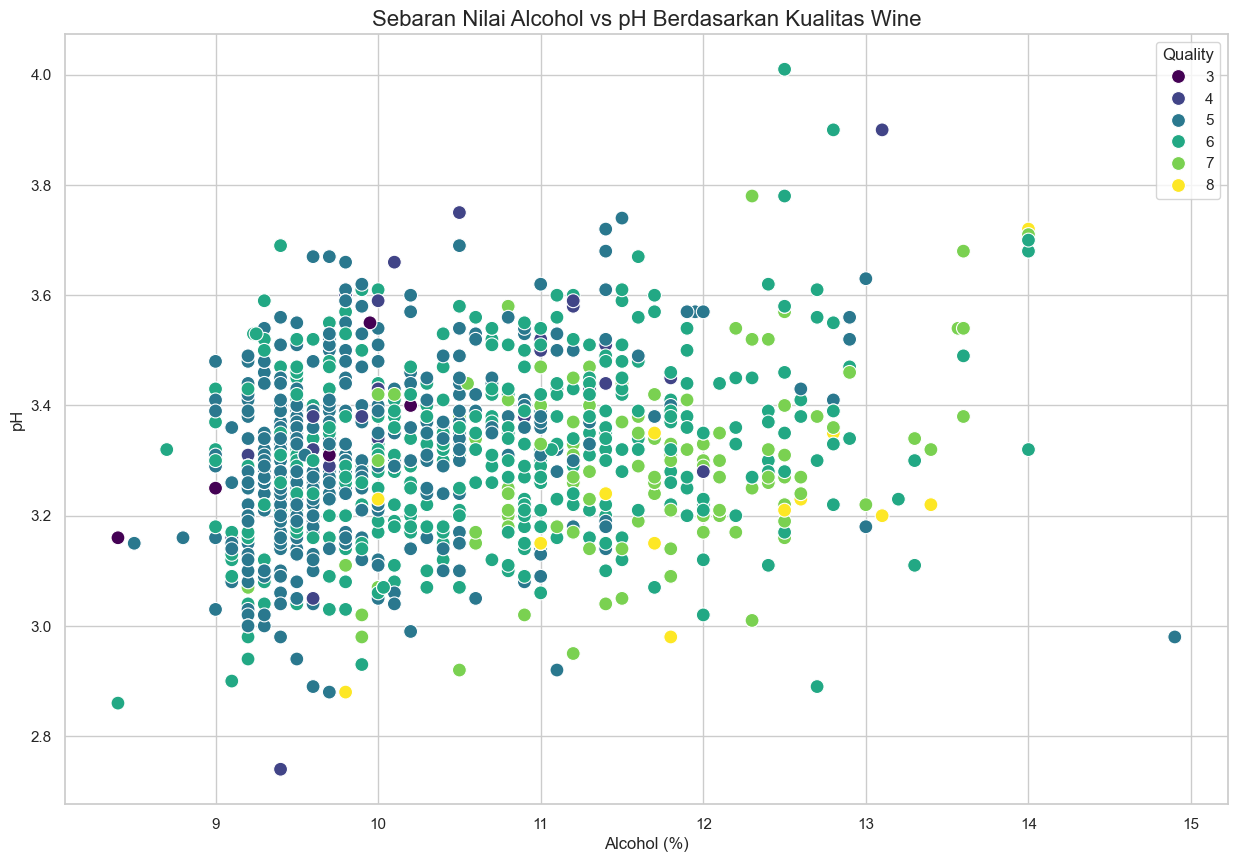

In [7]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='alcohol', y='pH', hue='quality', palette='viridis', s=100)

plt.title('Sebaran Nilai Alcohol vs pH Berdasarkan Kualitas Wine', fontsize=16)
plt.xlabel('Alcohol (%)', fontsize=12)
plt.ylabel('pH', fontsize=12)
plt.legend(title='Quality')

plt.show()

In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


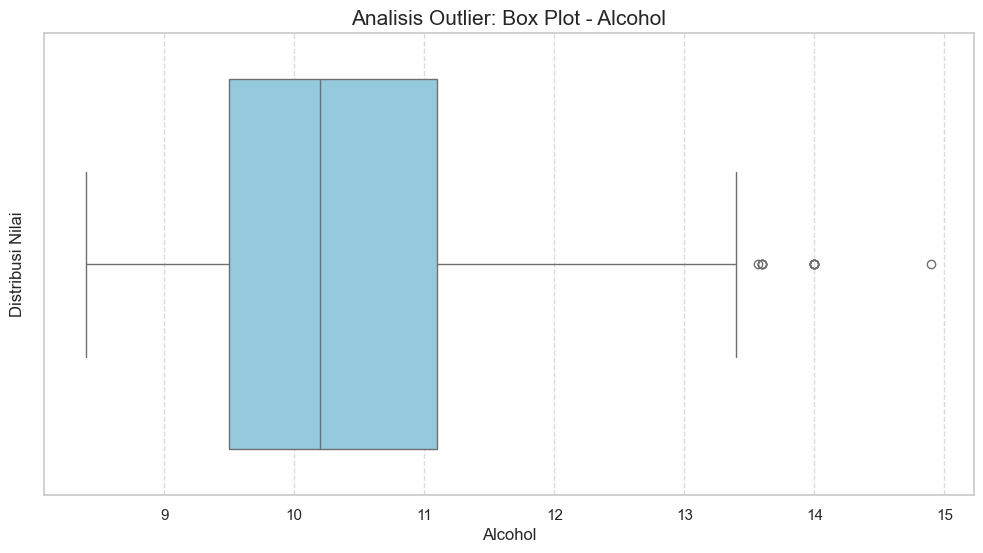

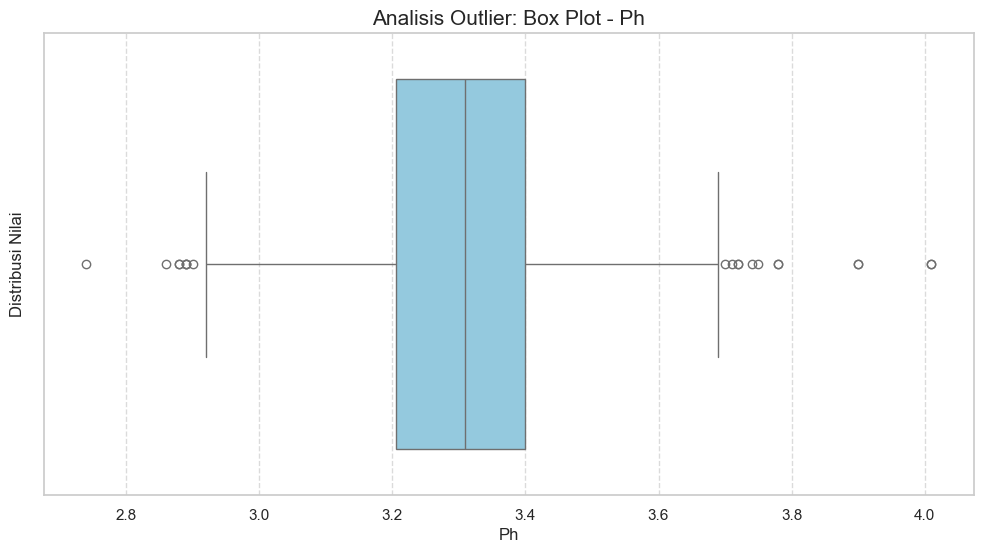

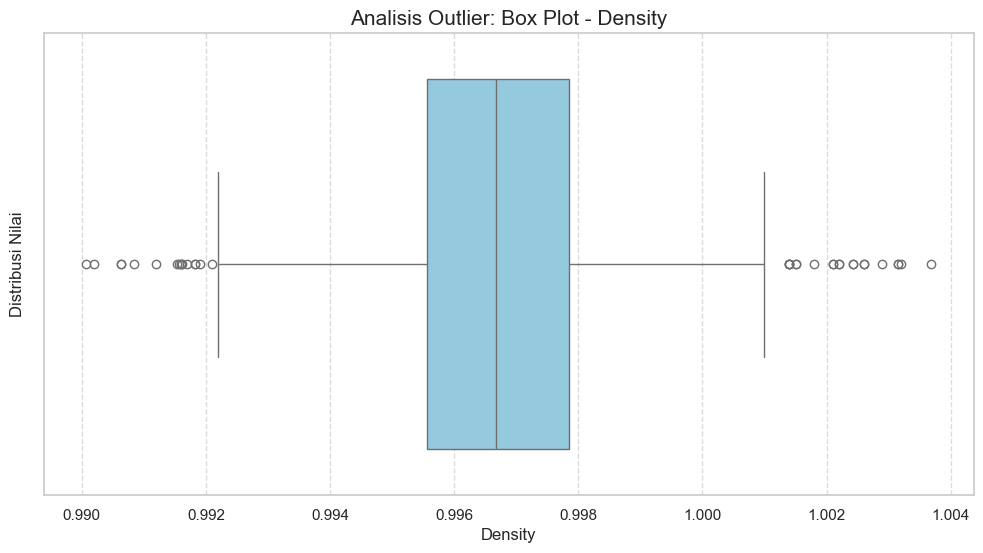

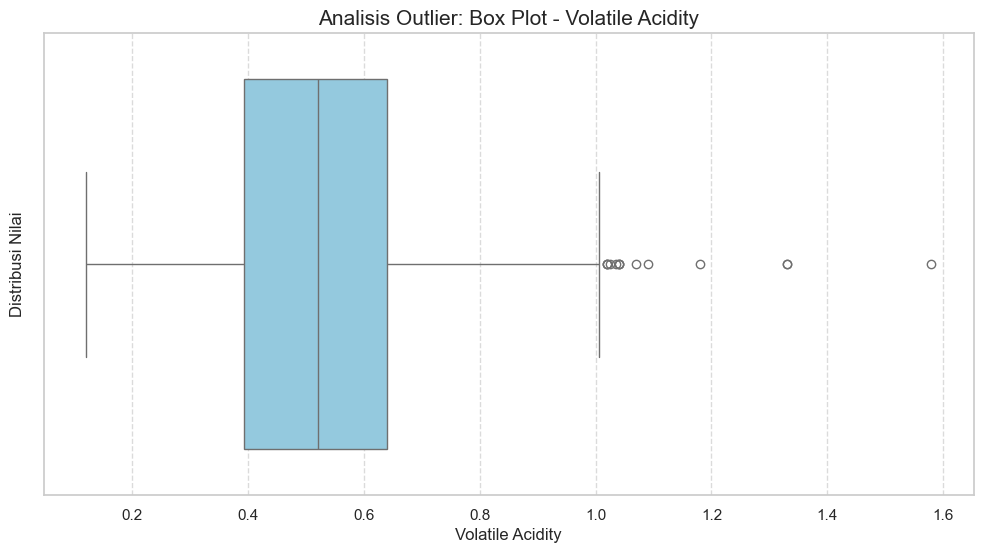

In [9]:
columns = ['alcohol', 'pH', 'density', 'volatile acidity']

for col in columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=df[col], color='skyblue')
    
    clean_title = col.replace('_', ' ').title()
    plt.title(f'Analisis Outlier: Box Plot - {clean_title}', fontsize=15)
    
    plt.xlabel(clean_title, fontsize=12)
    plt.ylabel('Distribusi Nilai')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.show()

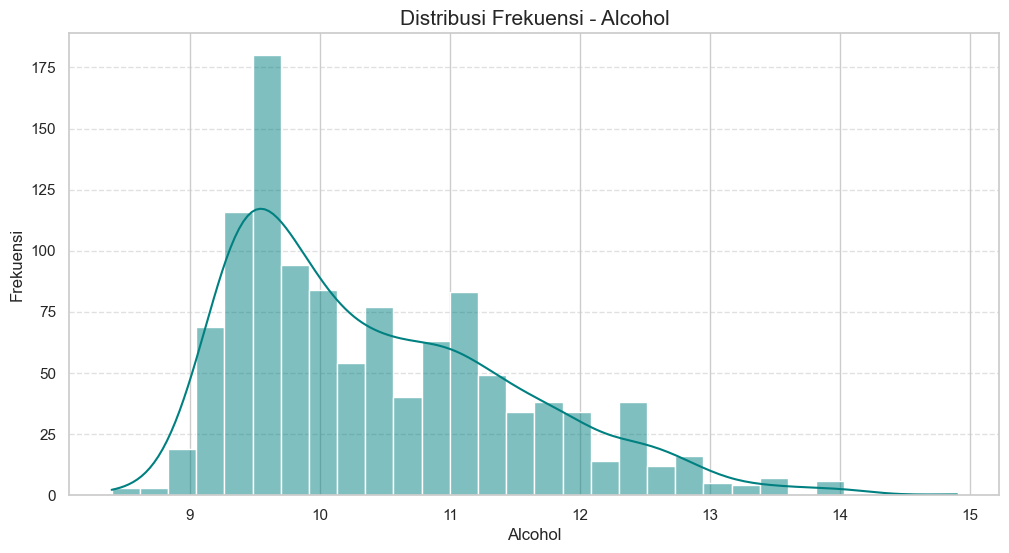

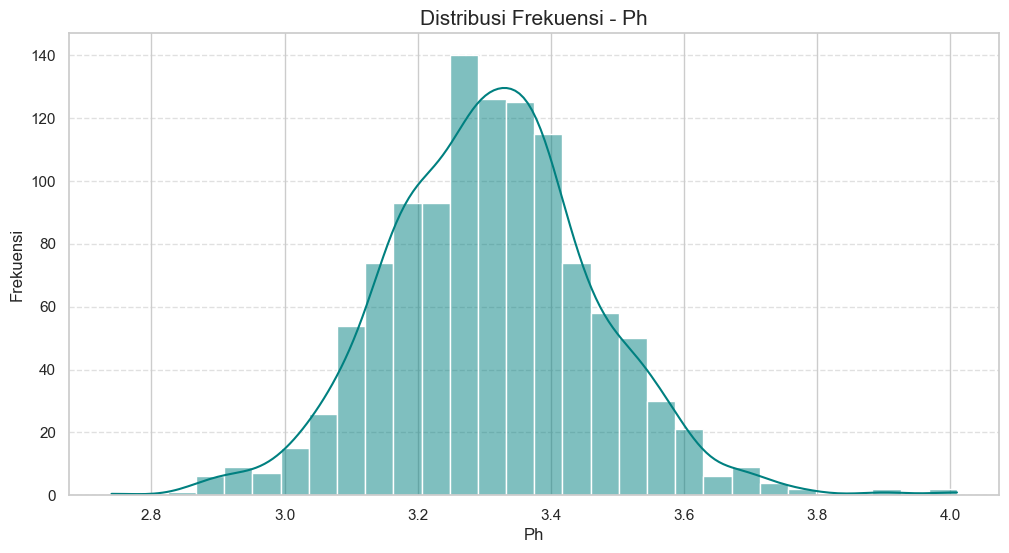

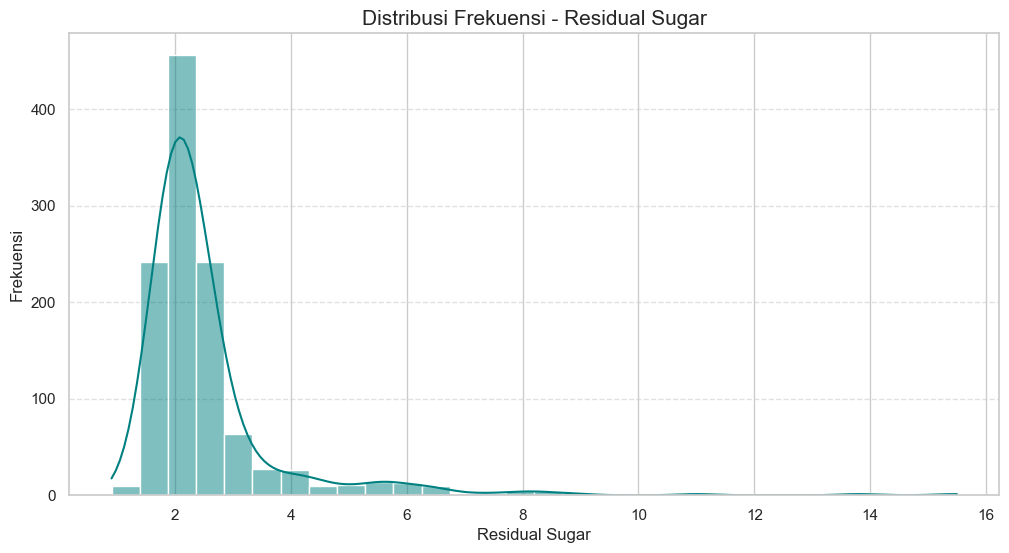

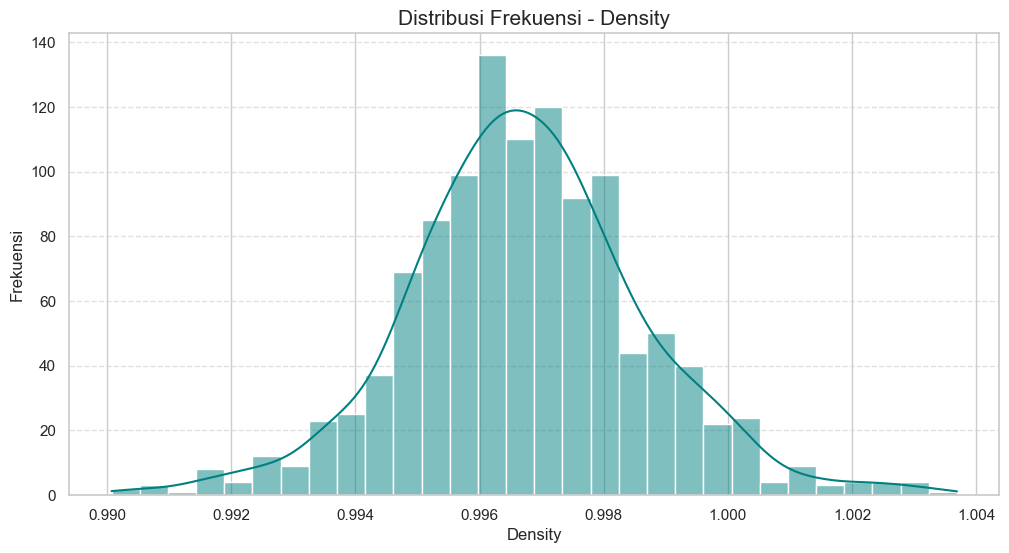

In [10]:
columns = ['alcohol', 'pH', 'residual sugar', 'density']

for col in columns:
    plt.figure(figsize=(12, 6))

    sns.histplot(df[col], bins=30, kde=True, color='teal')
    
    clean_name = col.replace('_', ' ').title()
    
    plt.title(f'Distribusi Frekuensi - {clean_name}', fontsize=15)
    plt.xlabel(clean_name, fontsize=12)
    plt.ylabel('Frekuensi')
    
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [11]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [12]:
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 
                 'density', 'pH', 'sulphates', 'alcohol']

X = df[fitur_columns].values
y = df['quality'].values 

print(f"Bentuk data X: {X.shape}")
print(f"Bentuk data y: {y.shape}")

Bentuk data X: (1143, 11)
Bentuk data y: (1143,)


In [13]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00


In [14]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, ...,  1.27069495,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, ..., -0.70892755,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.32577481,
        -0.04525363, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ...,  0.88754221,
        -0.45623467,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  1.33455374,
         0.60057372,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  1.65384769,
         0.30701583, -0.22382033]], shape=(1143, 11))

In [15]:
df_scalling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

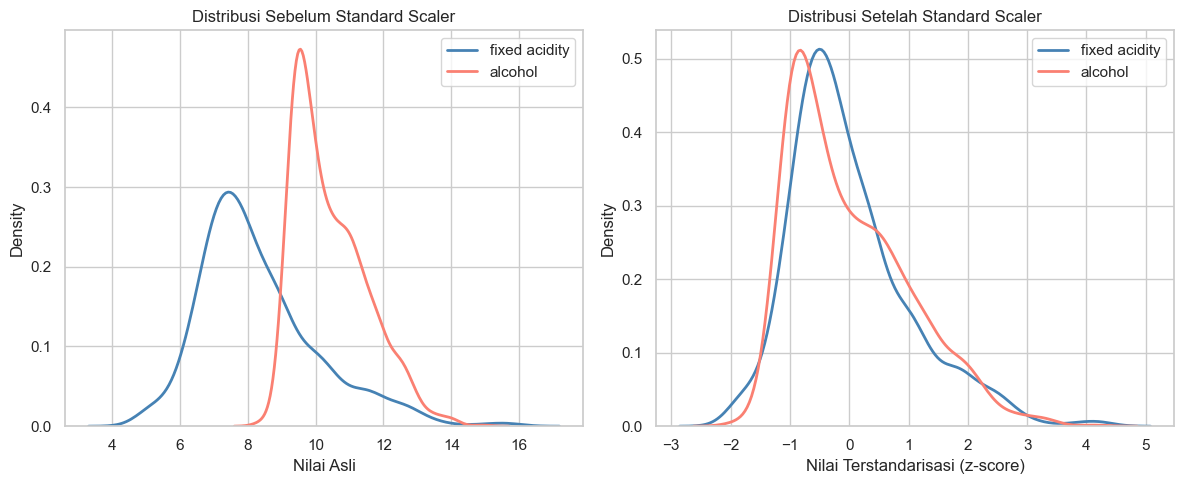

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Definisikan fitur yang ingin dibandingkan (contoh: fixed acidity dan alcohol)
# Kita ambil kolom tersebut dari dataframe 'df'
fitur_pilihan = ['fixed acidity', 'alcohol']
X = df[fitur_pilihan].values

# 2. Lakukan standarisasi (Scaling)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 3. Sekarang jalankan bagian plotting
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler
# X[:, 0] adalah 'fixed acidity', X[:, 1] adalah 'alcohol'
sns.kdeplot(X[:, 0], ax=ax1, label='fixed acidity', color='steelblue', linewidth=2)
sns.kdeplot(X[:, 1], ax=ax1, label='alcohol', color='salmon', linewidth=2)
ax1.set_title('Distribusi Sebelum Standard Scaler')

# Plot distribusi setelah Standar Scaler
# X_std[:, 0] adalah 'fixed acidity' ter-scale, X_std[:, 1] adalah 'alcohol' ter-scale
sns.kdeplot(X_std[:, 0], ax=ax2, label='fixed acidity', color='steelblue', linewidth=2)
sns.kdeplot(X_std[:, 1], ax=ax2, label='alcohol', color='salmon', linewidth=2)
ax2.set_title('Distribusi Setelah Standard Scaler')

# Set x-labels
ax1.set_xlabel('Nilai Asli')
ax2.set_xlabel('Nilai Terstandarisasi (z-score)')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Sebelum Standard Scaler Pada grafik ini nilai fitur "fixed acidity" dan "alcohol" masih berada pada rentang skala yang berbeda sehingga distribusinya belum seimbang.

2. Setelah Standard Scaler Pada grafik ini Data telah ditransformasikan sehingga memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Bentuk distribusi kedua fitur tetap relatif sama, namun skala nilainya menjadi lebih seragam.


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

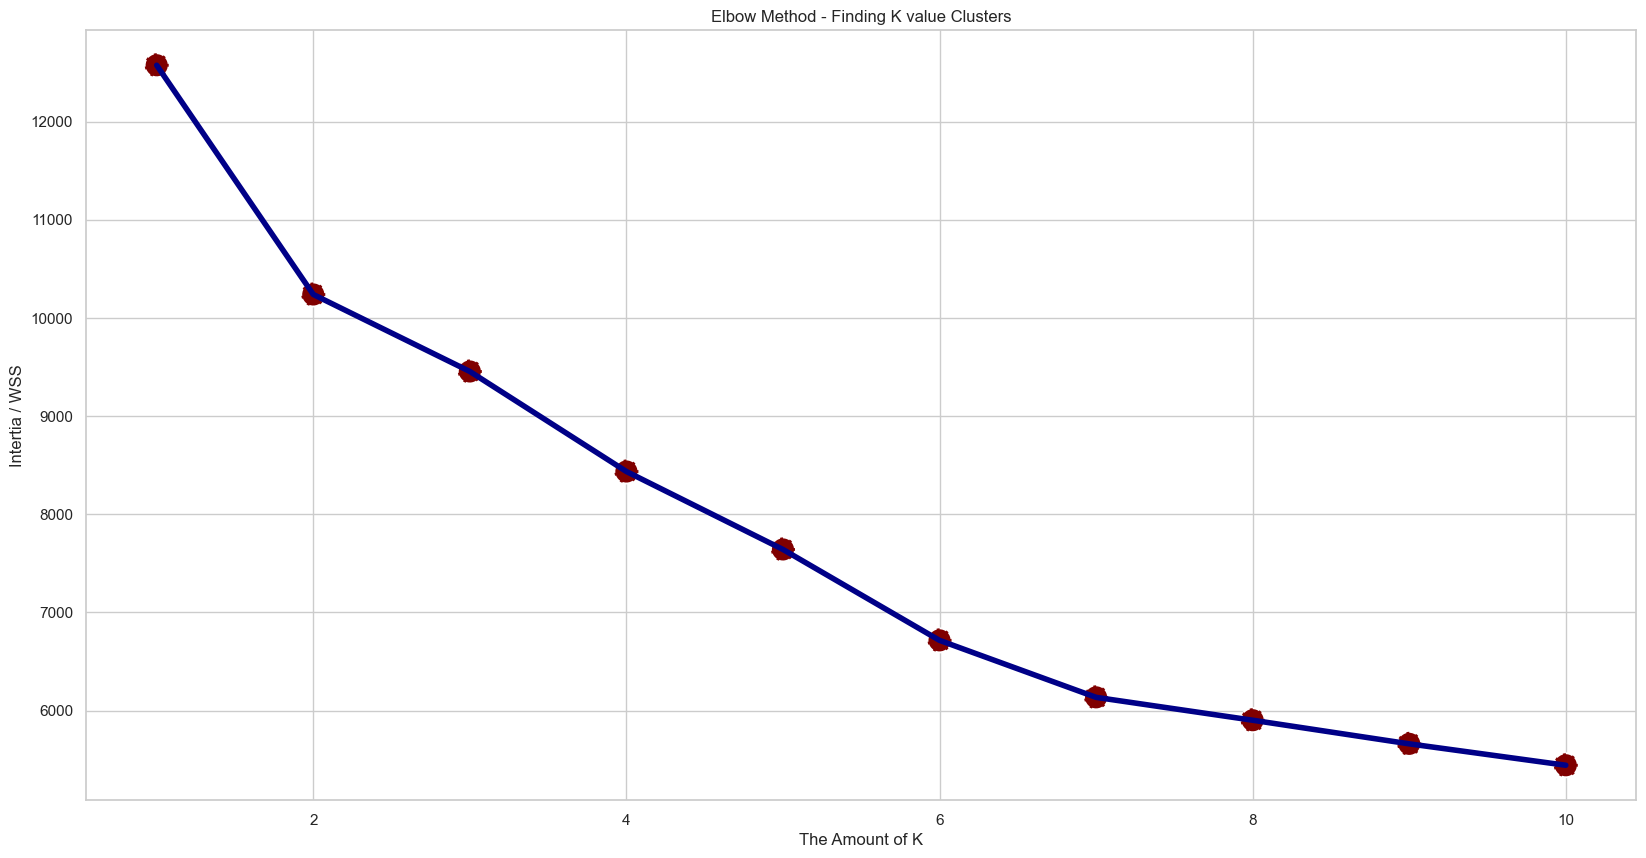

In [17]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [18]:
#Dari hasil diatas elbow nya dipilih pada angka 2,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=2, random_state=0)
kmeans_elbow.fit(df_scalling.values)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [19]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [20]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1


<Axes: xlabel='fixed acidity', ylabel='alcohol'>

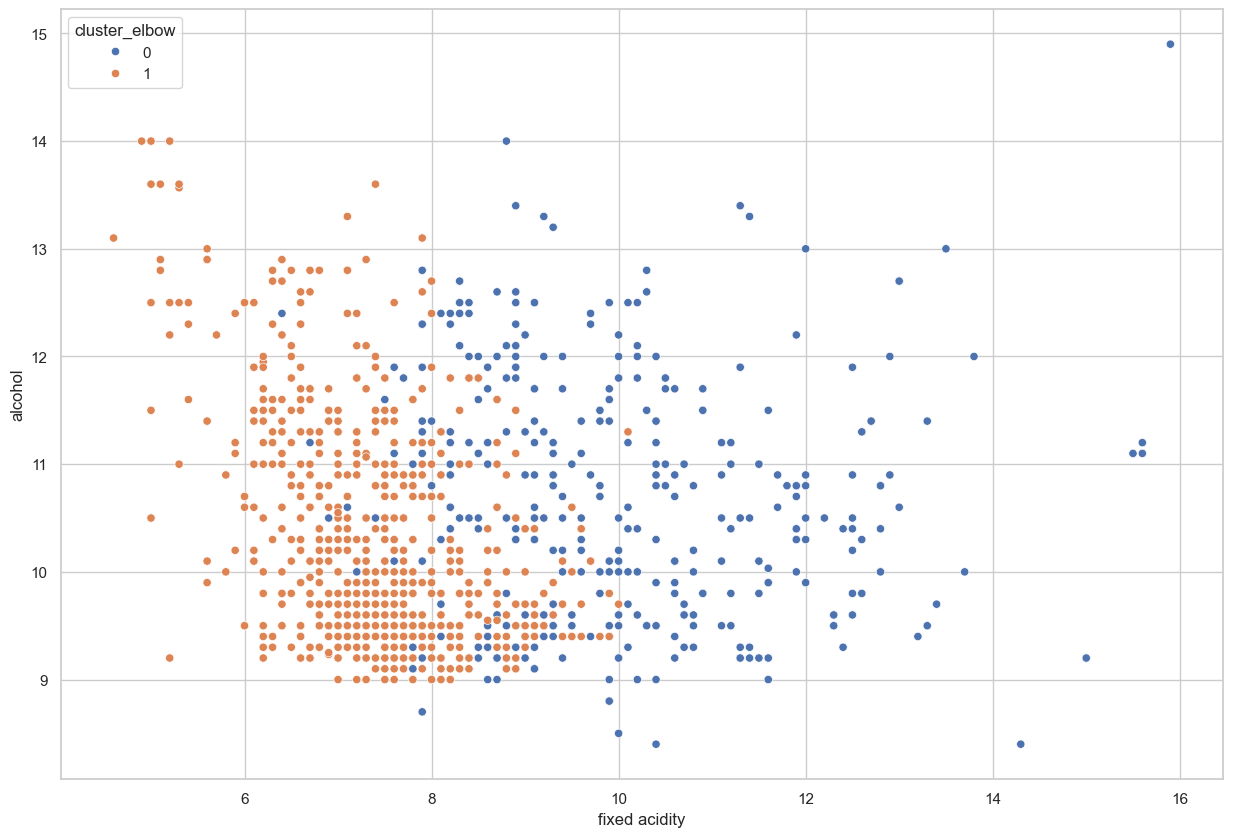

In [21]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='fixed acidity', ylabel='alcohol'>

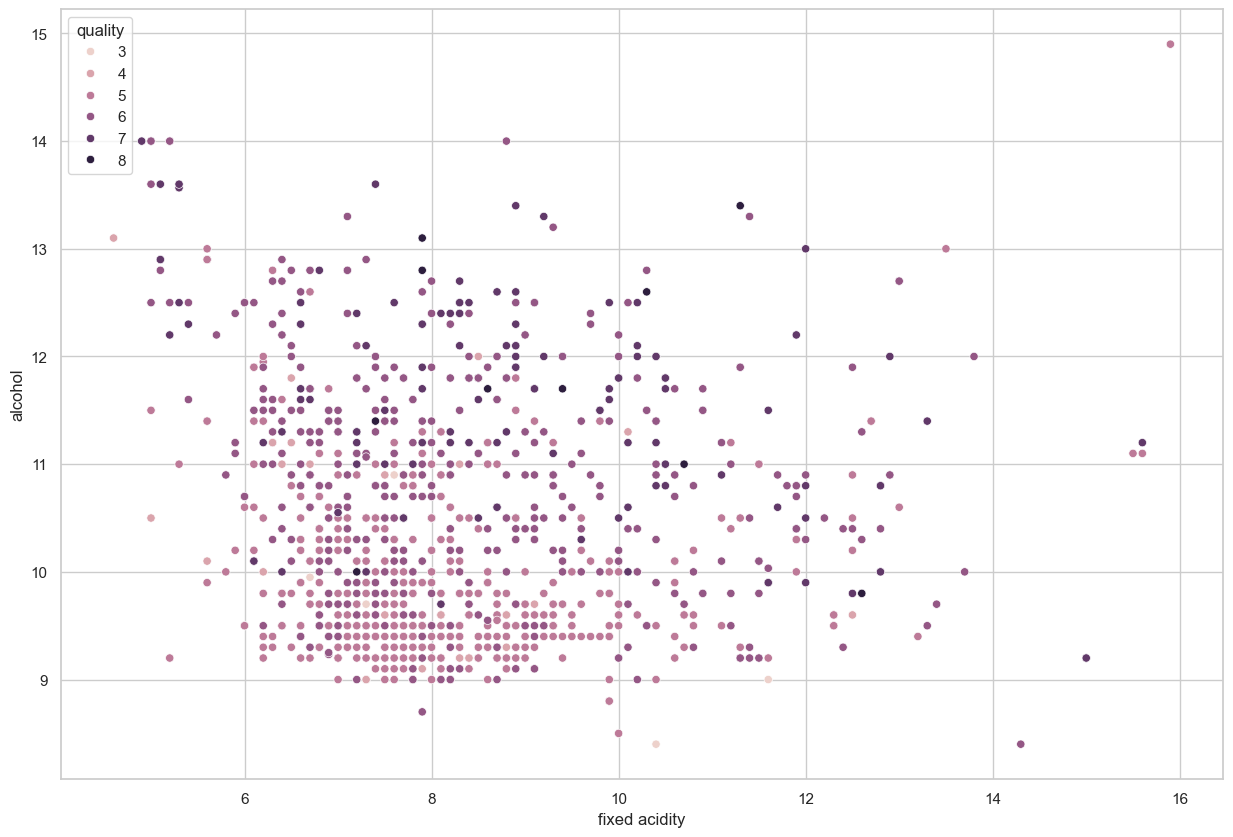

In [22]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol',hue='quality')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [23]:
!pip install yellowbrick


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\hp 645\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


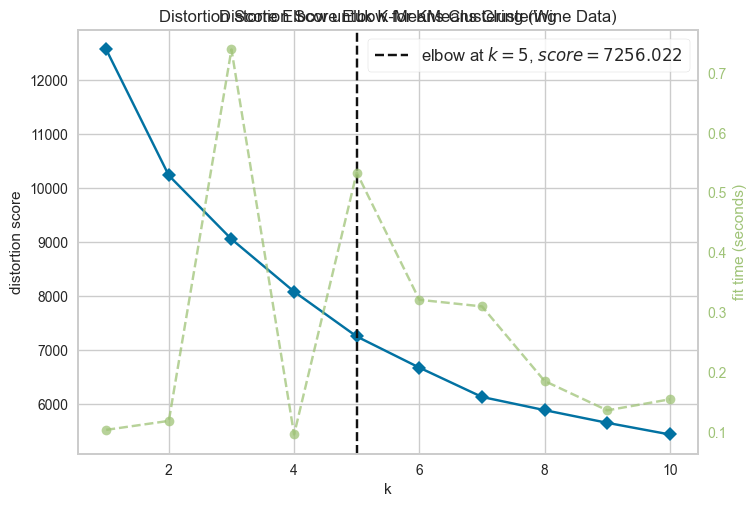

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer

df = pd.read_csv('WineQT.csv')
fitur = df.drop(['Id', 'quality'], axis=1)
scaler = StandardScaler()
df_scalling = scaler.fit_transform(fitur)
k_means_via = KMeans(n_init=10, random_state=42)
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings=True, force_model=True)
visualizer.fit(df_scalling)        
plt.title('Distortion Score Elbow untuk K-Means Clustering (Wine Data)')
visualizer.show()

In [27]:
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=5, random_state=0, n_init=10)

kmeans_via.fit(df_scalling) 

df['cluster_via'] = kmeans_via.labels_

In [28]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [29]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,4
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,0
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,0
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,0
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,2


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

<Axes: xlabel='fixed acidity', ylabel='alcohol'>

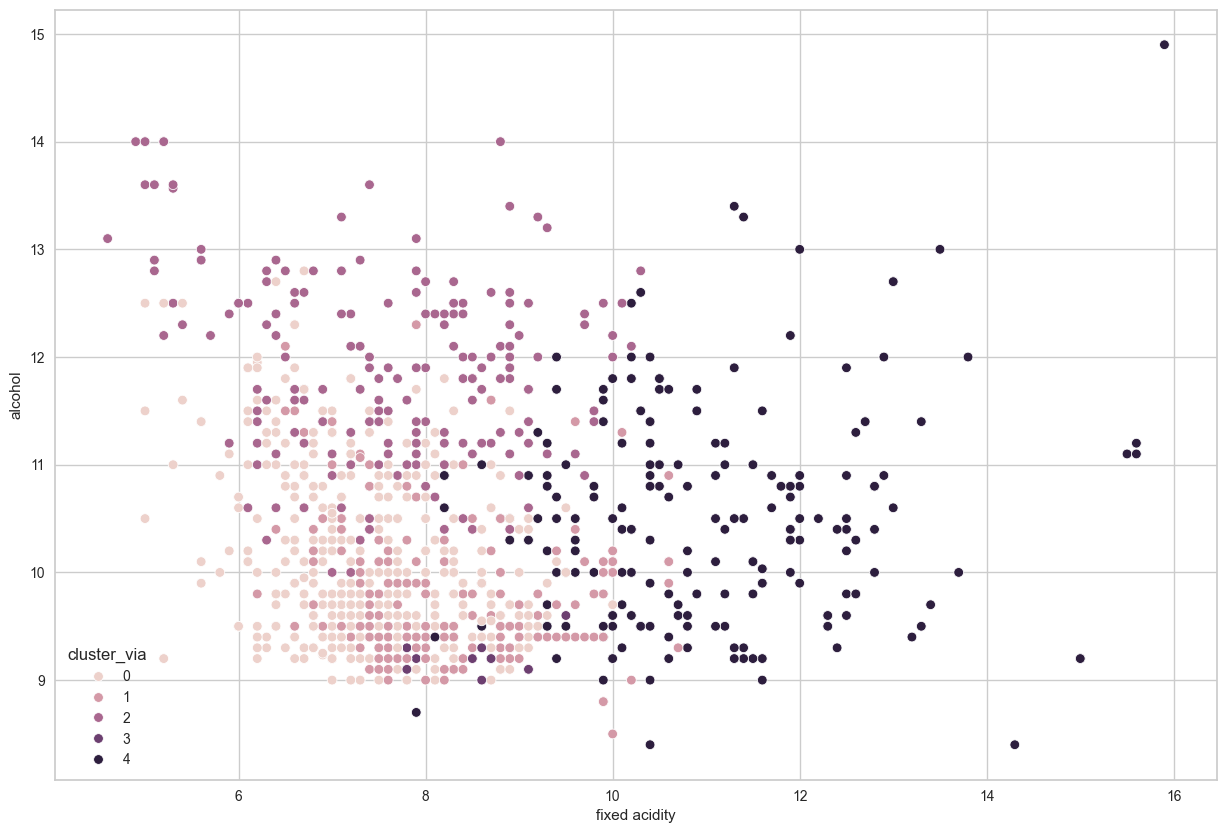

In [30]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='cluster_via')

### Bandingkan dengan label anotator

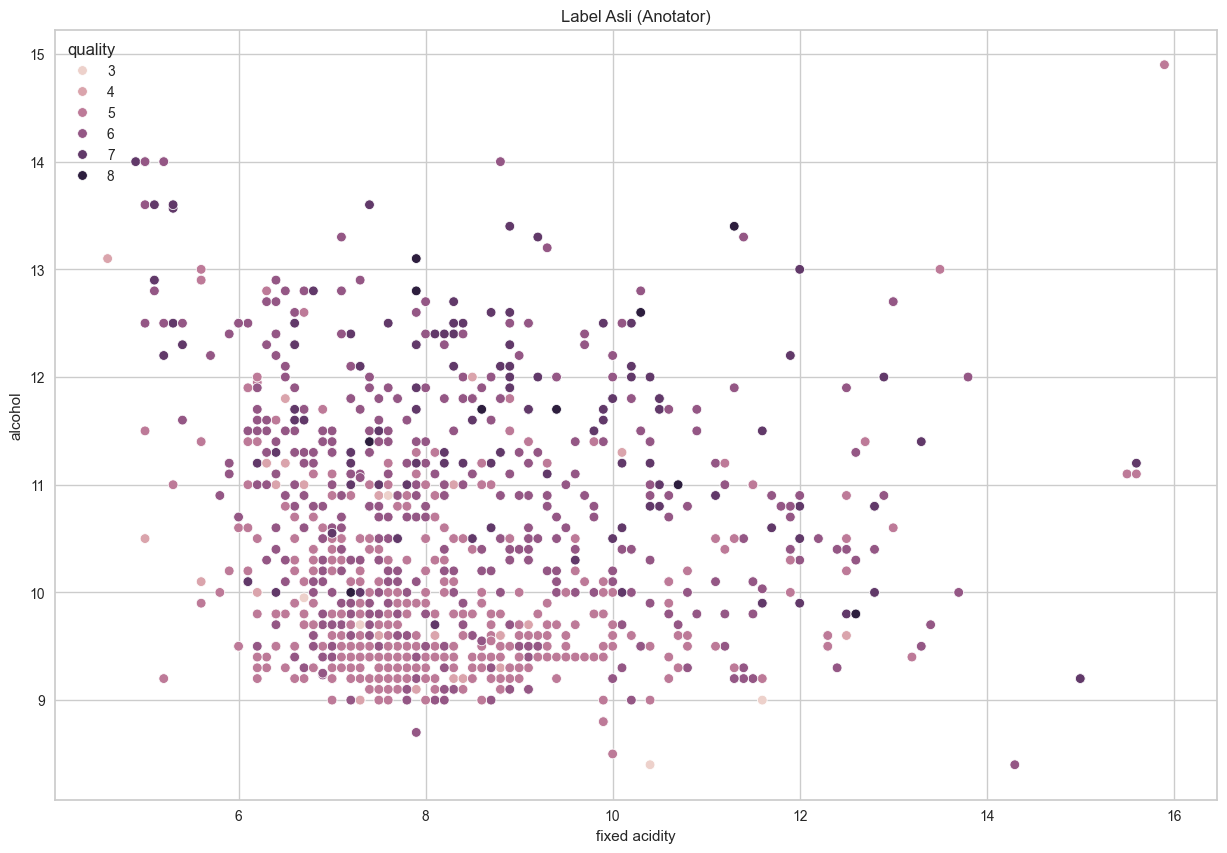

In [31]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='quality')
plt.title('Label Asli (Anotator)')
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
Hasil clustering K-Means menunjukkan pola pengelompokan data yang cukup baik, tetapi belum sepenuhnya memenuhi label kualitas yang diberikan pada awalnya. Ini disebabkan oleh fakta bahwa fitur "fixed acidity" dan "alcohol" masih memiliki overlap antar kelas, yang berarti bahwa beberapa jenis wine termasuk dalam kelompok yang sama.

### Thank you :)